# Phase 4: Feature Engineering & Model Building
This notebook covers the model training pipeline for the AI-Powered Job Fraud Detection project. We vectorize the cleaned text using TF-IDF, address class imbalance with balanced weights, train a Logistic Regression classifier, evaluate its performance, and export the trained model artifacts.

In [42]:
%pip install xgboost
%pip install lightgbm

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
  Using cached lightgbm-4.6.0-py3-none-win_amd64.whl.metadata (17 kB)
Using cached lightgbm-4.6.0-py3-none-win_amd64.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [46]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
import os
import joblib

# We use a VotingClassifier Ensemble to improve accuracy and balance bias.
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

lr = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
nb_clf = MultinomialNB()

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
import warnings
warnings.filterwarnings('ignore')


In [55]:
# Load cleaned dataset
df = pd.read_csv('cleaned_jobs.csv')
df['text'] = df['text'].fillna('')

print(f"Dataset shape: {df.shape}")
print(f"Genuine postings: {sum(df['fraudulent'] == 0)}")
print(f"Fraudulent postings: {sum(df['fraudulent'] == 1)}")

Dataset shape: (17880, 19)
Genuine postings: 17014
Fraudulent postings: 866


## 1. Train-Test Split

In [56]:
X = df['text']
y = df['fraudulent']

# 80% train, 20% test split, stratified to preserve class ratios
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## 2. Text Vectorization using TF-IDF

In [57]:
vectorizer = TfidfVectorizer(
    max_features=20000,
    ngram_range=(1,2),
    stop_words='english',
    min_df=2,
    max_df=0.95,
    sublinear_tf=True
)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"TF-IDF shape (Train): {X_train_tfidf.shape}")

TF-IDF shape (Train): (14304, 20000)


## 3. Model Training (Stacking Classifier with SMOTE and Tuning)

In [59]:
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.model_selection import RandomizedSearchCV
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Faster SVM
svm_clf = LinearSVC(
    C=1.0,
    class_weight='balanced',
    random_state=42
)

# Reduce trees
xgb_clf = XGBClassifier(
    n_estimators=50,
    max_depth=3,
    learning_rate=0.1,
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

lgbm_clf = LGBMClassifier(
    n_estimators=50,
    learning_rate=0.1,
    num_leaves=20,
    class_weight='balanced',
    random_state=42,
    verbose=-1
)

lr_meta = LogisticRegression(
    max_iter=2000,
    class_weight='balanced'
)

stacking_clf = StackingClassifier(
    estimators=[
        ('svm', svm_clf),
        ('xgb', xgb_clf),
        ('lgbm', lgbm_clf)
    ],
    final_estimator=lr_meta,
    cv=2,
    passthrough=False,
    n_jobs=-1
)

param_dist = {
    'xgb__n_estimators': [30, 50],
    'lgbm__n_estimators': [30, 50]
}

random_search = RandomizedSearchCV(
    estimator=stacking_clf,
    param_distributions=param_dist,
    n_iter=1,          # only one search
    cv=2,
    scoring='f1',
    n_jobs=-1,
    verbose=2,
    random_state=42
)

random_search.fit(X_train_tfidf, y_train)

model = random_search.best_estimator_

Fitting 2 folds for each of 1 candidates, totalling 2 fits


## 4. Evaluation

Best Parameters: {'xgb__n_estimators': 50, 'lgbm__n_estimators': 30}

Accuracy:  0.9575
Precision: 0.5344
Recall:    0.9422
F1 Score:  0.6820
ROC-AUC:   0.9919

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.96      0.98      3403
           1       0.53      0.94      0.68       173

    accuracy                           0.96      3576
   macro avg       0.77      0.95      0.83      3576
weighted avg       0.97      0.96      0.96      3576



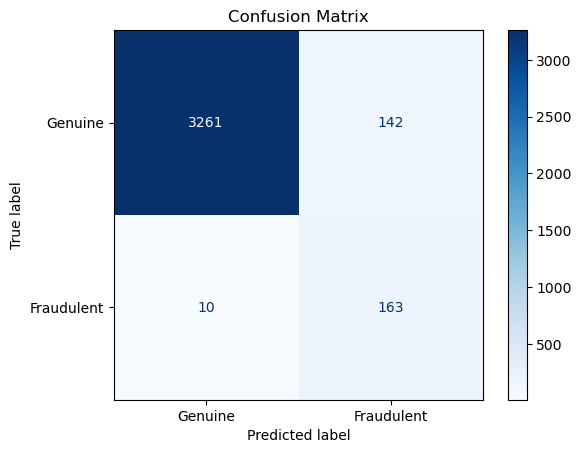

In [60]:
y_pred = model.predict(X_test_tfidf)
y_pred_proba = model.predict_proba(X_test_tfidf)[:, 1]

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Best Parameters: {random_search.best_params_}\n")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Genuine', 'Fraudulent'])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.show()


## 5. Exporting Model & Vectorizer

In [61]:
os.makedirs('model', exist_ok=True)
joblib.dump(model, 'model/fraud_detector.pkl')
joblib.dump(vectorizer, 'model/tfidf_vectorizer.pkl')
print("Model artifacts saved successfully!")

Model artifacts saved successfully!
